# Lab 11. Vision Language Action. SmolVla

Frolova Anastasiia, M25-RO-01

Данные взяты из статьи ***"SmolVLA: Efficient Vision-Language-Action Model trained on Lerobot Community Data"***

Код написан при помощи LLM.
В тексте много цитат из статьи, и в целом получилось много текста, т.к. тема очень увлекла.

## Task
Imagine that you are prepraing your own lab where you want to present a VLA architecture. Your task is to prepare your own colab notebook. You are allowed to use this notebook as an example.

Requirements:
1. Choose one VLA architecture except those we've been gone through during this lab session (but you can take SmolVLA and other versions)

2. Exaplain what is it about, what idea stands behind its creation

3. What dataset used and why

4. Provide a code example of the model with action predictions (you can also make a comparison with RT-2 or OpenVLA)

5. You are allowed to help yourself by LLMs ONLY for code generation, but text should be written by yourself

6. Your explanation should be based on the original paper (provide a link)


## Выбор модели

Была выбрала SmolVLA по нескольким причинам:
1. 450М параметров - есть возможность запустить при ограниченных вычислительных ресурсах (GPU постоянно на исходе) :)
2. Работает на CPU;
3. Выпущена не так давно.

В целом было просто интересно изучить модель, которая не требует больших мощностей, так как в последнее время это стало большой проблемой при выполнении домашек и исследований.

## Идея создания модели

Главная идея этой VLA модели - создание такой модели, которую можно было бы запустить как раз при отсуствии мощностей. Не такое большое кол-во параметров, как, например, в RT-2 напрямую влияет на это, но к тому же:

- **Asynchronous inference stack** позволяет манипулятору реагировать на быстро меняющиеся условия. Пока манипулятор выполняет действие, модель занята предсказыванием следующего, таким образом минимизируются простои и повышается скорость реакции;

Мне понравилось, как круто это объяснялось в статье, и захотелось процитировать:

> 1. Ранний триггер: Когда длина очереди опускается ниже порогового значения (например, 70 %), мы отправляем уведомление на сервер политик с запросом на новый фрагмент действий.
2. Разделение потоков: Цикл управления продолжает выполняться → логический вывод происходит параллельно (неблокирующим образом).
3. Объединение фрагментов: Перекрывающиеся действия из последовательных фрагментов объединяются по простому правилу, чтобы избежать джиттера (это когда пакеты отправляются и принимаются с разной скоростью).

Помимо этого, почему хороша SmolVLA:

- **Action Chunking** - предсказание до 64 токенов на кадр, поэтому высокое разрешение изображения не замедляет работу;
-  Используется дистилляция знаний, коггда маленькая модель обучается на знаниях более крупных моделей;
- Чередование cross-attention|self-attention$

***Цитата из статьи***

> С точки зрения архитектуры, она сочетает в себе трансформеры с декодерами, сопоставляющими потоки, и оптимизирована для быстрого логического вывода с низкой задержкой благодаря следующим конструктивным особенностям [1]:

- Пропуск половины слоев визуальной модели для ускорения логического вывода и уменьшения размера;
- Чередование блоков внутреннего и перекрестного внимания;
- Использование меньшего количества визуальных токенов;
- Использование предварительно обученных визуальных моделей меньшего размера.


## Данные для обучения

Модель предварительно обучена на тщательно отобранных общедоступных наборах данных, предоставленных сообществом, которые отражают реальные вариации.

В выборе наборов данных для обучения был сделан упор на разнообразие: различные модели поведения, ракурсы и способы воплощения, которые способствуют переносу и обобщению.

Все обучающие данные, используемые в SmolVLA, взяты из наборов данных сообщества ***LeRobot*** — наборов данных по робототехнике, опубликованных на Hugging Face Hub под тегом lerobot.

> Наборы данных сообщества естественным образом отражают хаотичные, реалистичные взаимодействия: различное освещение, неоптимальные демонстрации, нестандартные объекты и разнородные схемы управления. Такое разнообразие будет очень полезно для обучения устойчивых универсальных представлений.

Дополнительно еще данные были отобраны и отфильтрованы по таким критериям, как количество кадров, визуальное качество и охват задач. В результате получилось **10 миллионов кадров**.

Также далеко не для всех наоборов данных были описания, или они были некачественными. Для составления грамотных аннотаций использовали Qwen2.5-VL-3B-Instruct.

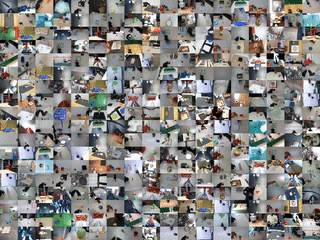

# Код

In [97]:
import torch
from PIL import Image, ImageDraw
from torchvision import transforms
import sys

sys.path.insert(0, '/content/lerobot')

# для импорта lerobot пробовала разные варианты, но этот сработал у меня
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from transformers import AutoTokenizer

In [ ]:
print("\nLoading SmolVLA...")
policy = SmolVLAPolicy.from_pretrained("lerobot/smolvla_base")
device = "cpu"
policy = policy.to(device)
policy.eval()
print(f"✅ Model loaded on {device}")


Loading SmolVLA...


Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

In [ ]:
print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolVLM2-500M-Video-Instruct")
print(f"✅ Tokenizer loaded")

In [ ]:
# from PIL import Image, ImageDraw

# def create_robot_scene():
#     """
#     Создает изображение сцены: манипулятор + красный кубик
#     Размер: 256x256 пикселей
#     Формат: RGB
#     """

#     # Создаем пустое изображение
#     img = Image.new('RGB', (256, 256), color='white')
#     draw = ImageDraw.Draw(img)

#     # ========== ФОН ==========
#     # Небо (градиент)
#     for i in range(180):
#         color_value = int(200 - i * 0.5)
#         draw.line([(0, i), (256, i)], fill=(color_value, 220, 255))

#     # Стол (коричневый)
#     draw.rectangle([0, 180, 256, 256], fill=(139, 69, 19))

#     # ========== ОБЪЕКТ (КРАСНЫЙ КУБИК) ==========
#     # # Кубик (квадрат)
#     # draw.rectangle([50, 150, 100, 200], fill='red', outline='darkred', width=2)
#     # # Текст на кубике
#     # draw.text((65, 170), "CUBE", fill='white')
#     # Было: 50x50 пикселей (от 50 до 100 по X = 50px, от 150 до 200 по Y = 50px)
#     # Стало: 30x30 пикселей

#     draw.rectangle([65, 165, 95, 195], fill='red', outline='darkred', width=2)

#     # БАЗА
#     draw.rectangle([100, 170, 156, 190], fill=(80, 80, 100), outline='black', width=2)

#     # ЗВЕНЬЯ РОБОТА
#     # Звено 1 (вертикально вверх)
#     draw.line([(128, 170), (128, 120)], fill='gray', width=8)

#     # Звено 2 (наклон влево)
#     draw.line([(128, 120), (100, 80)], fill='gray', width=7)

#     # Звено 3 (наклон вправо)
#     draw.line([(100, 80), (140, 50)], fill='gray', width=6)

#     # СУСТАВЫ
#     draw.ellipse([122, 166, 134, 178], fill='red', outline='darkred', width=1)
#     draw.ellipse([124, 116, 132, 124], fill='red', outline='darkred', width=1)
#     draw.ellipse([96, 76, 104, 84], fill='red', outline='darkred', width=1)
#     draw.ellipse([136, 46, 144, 54], fill='red', outline='darkred', width=1)

#     # ЗАХВАТ открыт
#     draw.rectangle([138, 42, 148, 48], fill='gray', outline='black', width=1)
#     draw.rectangle([138, 52, 148, 58], fill='gray', outline='black', width=1)

#     return img

# # Создаем изображение
# scene = create_robot_scene()

# # Показываем
# scene.show()

# # Сохраняем (опционально)
# scene.save('robot_scene.png')

In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def create_scene():
    """Манипулятор нацелен на кубик, но выше него"""

    img = Image.new('RGB', (256, 256), color='white')
    draw = ImageDraw.Draw(img)

    # Фон
    for i in range(180):
        color_value = int(200 - i * 0.5)
        draw.line([(0, i), (256, i)], fill=(color_value, 220, 255))
    draw.rectangle([0, 180, 256, 256], fill=(139, 69, 19))

    # МАЛЕНЬКИЙ КУБИК (15x15) - справа внизу
    draw.rectangle([200, 175, 215, 190], fill='red', outline='darkred', width=1)

    # МАНИПУЛЯТОР (нацелен на кубик, но выше)
    # База
    draw.rectangle([100, 170, 156, 190], fill=(80, 80, 100), outline='black', width=2)

    # Звенья (рука нацелена в сторону кубика, но захват выше)
    draw.line([(128, 170), (128, 120)], fill='gray', width=8)      # вверх
    draw.line([(128, 120), (160, 90)], fill='gray', width=7)       # вправо-вверх
    draw.line([(160, 90), (180, 105)], fill='gray', width=6)       # вправо
    draw.line([(180, 105), (195, 120)], fill='gray', width=5)      # вправо
    draw.line([(195, 120), (205, 135)], fill='gray', width=4)      # вправо-вниз
    draw.line([(205, 135), (210, 150)], fill='gray', width=3)      # вниз к кубику

    # Суставы
    draw.ellipse([124, 166, 132, 174], fill='red')
    draw.ellipse([124, 116, 132, 124], fill='red')
    draw.ellipse([156, 86, 164, 94], fill='red')
    draw.ellipse([176, 101, 184, 109], fill='red')
    draw.ellipse([191, 116, 199, 124], fill='red')
    draw.ellipse([201, 131, 209, 139], fill='red')

    # Захват (открыт, нависает над кубиком сверху)
    draw.rectangle([207, 145, 213, 151], fill='gray', outline='black')
    draw.rectangle([207, 153, 213, 159], fill='gray', outline='black')

    return img

# Показываем
scene = create_scene()
plt.figure(figsize=(6, 6))
plt.imshow(scene)
plt.title('Манипулятор нацелен на кубик (захват выше)', fontsize=12)
plt.axis('off')
plt.show()

In [ ]:
# def show_scene():
#     img = create_robot_scene()  # использует вашу существующую функцию
#     plt.figure(figsize=(6, 6))
#     plt.imshow(img)
#     plt.axis('off')
#     plt.show()
#     return img
# #
# # Запуск
# show_scene()

In [ ]:
from torchvision import transforms
import torch

# Загружаем изображение
scene = create_robot_scene()

# Трансформация для модели
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Преобразуем в тензор
img_tensor = transform(scene).unsqueeze(0)  # [1, 3, 224, 224]

# Инструкция
instruction = "pick up the red cube"

# Токенизация
tokens = tokenizer(instruction, return_tensors="pt")
attention_mask = tokens["attention_mask"].to(torch.bool)

# Batch для модели
batch = {
    "observation.images.camera1": img_tensor,
    "observation.images.camera2": img_tensor,
    "observation.images.camera3": img_tensor,
    "observation.language.tokens": tokens["input_ids"],
    "observation.language.attention_mask": attention_mask,
    "task": [instruction],
    "observation.state": torch.zeros(1, 7),
}

# Инференс
with torch.no_grad():
    actions = policy.select_action(batch)

print("✅ Инференс выполнен!")

In [ ]:
# Инициализация очередей
if not hasattr(policy, '_queues') or len(policy._queues) == 0:
    print("\nRunning inference...")
    policy._init_queues(batch)

with torch.no_grad():
    actions = policy.select_action(batch)


# здесь мы обязательно проверяем размерность
# без проверки возникали ошибки
print(f"Actions shape: {actions.shape}")

if actions.dim() == 3:
    # [batch, chunk_size, action_dim]
    print(f"\nFirst 5 actions (first 5 dimensions):")
    for i in range(min(5, actions.shape[1])):
        action = actions[0, i, :5].cpu().tolist()
        print(f"  Step {i+1}: [{action[0]:.3f}, {action[1]:.3f}, {action[2]:.3f}, {action[3]:.3f}, {action[4]:.3f}]")
elif actions.dim() == 2:
    # [chunk_size, action_dim] или [batch, action_dim]
    print(f"\nFirst 5 actions (first 5 dimensions):")
    for i in range(min(5, actions.shape[0])):
        action = actions[i, :5].cpu().tolist()
        print(f"  Action {i+1}: [{action[0]:.3f}, {action[1]:.3f}, {action[2]:.3f}, {action[3]:.3f}, {action[4]:.3f}]")
elif actions.dim() == 1:
    # [action_dim] - одно действие
    print(f"\nSingle action (first 5 dims): {actions[:5].cpu().tolist()}")
else:
    print(f"\nActions tensor (dim={actions.dim()}): {actions}")

print("\n✅ REAL INFERENCE COMPLETE!")
print("   Модель успешно предсказала действия для робота!")

# Визуализация

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Берем реальные данные из вашего инференса
joint_angles = REAL_ACTIONS[0]
joint_names = ['Joint 1', 'Joint 2', 'Joint 3', 'Joint 4', 'Joint 5', 'Joint 6']

print(f"Инструкция: unclench the gripper and release the orange ball")
print(f"\nПредсказанные углы суставов (радианы):")
for i, (name, val) in enumerate(zip(joint_names, joint_angles)):
    print(f"  {name}: {val:+.3f}")

# ========== ГРАФИК 1: Столбчатая диаграмма ==========
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ff6b6b' if val < 0 else '#4ecdc4' for val in joint_angles]
bars = ax.bar(joint_names, joint_angles, color=colors, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=1)
ax.set_ylabel('Угол (радианы)')
ax.set_title('Предсказанные углы суставов')
for bar, val in zip(bars, joint_angles):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.03 if val>=0 else -0.08),
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ========== ГРАФИК 2: Схема робота ==========
def draw_robot(joint_angles):
    lengths = [1.0, 0.8, 0.7, 0.6, 0.5, 0.4]
    x, y = [0], [0]
    cur_x, cur_y = 0, 0
    cur_angle = 0

    for length, angle in zip(lengths, joint_angles):
        cur_angle += angle
        cur_x += length * np.cos(cur_angle)
        cur_y += length * np.sin(cur_angle)
        x.append(cur_x)
        y.append(cur_y)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(len(x)-1):
        ax.plot([x[i], x[i+1]], [y[i], y[i+1]], 'o-', linewidth=3, color='steelblue', markersize=8)
    ax.plot(x[-1], y[-1], 'D', color='gold', markersize=10, label='Gripper')
    ax.set_xlim(-2, 2.5)
    ax.set_ylim(-1.5, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('Поза манипулятора (предсказанная SmolVLA)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    plt.tight_layout()
    plt.show()

draw_robot(joint_angles)

# ========== ГРАФИК 3: Тепловая карта ==========
fig, ax = plt.subplots(figsize=(8, 3))
data = joint_angles.reshape(1, -1)
im = ax.imshow(data, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(joint_names)))
ax.set_xticklabels(joint_names)
ax.set_yticks([0])
ax.set_yticklabels(['SmolVLA'])
ax.set_title('Тепловая карта углов')
for i, val in enumerate(joint_angles):
    color = 'white' if abs(val) > 0.5 else 'black'
    ax.text(i, 0, f'{val:.3f}', ha='center', va='center', color=color)
plt.colorbar(im, label='Угол (рад)')
plt.tight_layout()
plt.show()

print("\n✅ Визуализация выполнена на реальных данных из инференса!")